In [11]:
import os
import re
import pandas as pd

root = r"C:\Users\cronk\.vscode\Sticky_Dumbbell_MS_Project\Fits_folder"   # parent of the five sub‑folders
folders = sorted(
    os.path.join(root, d) for d in os.listdir(root)
    if os.path.isdir(os.path.join(root, d))
)

df_by_folder = {}        # will hold one DataFrame per folder

for folder in folders:
    rows   = []          # list of one‑row DataFrames
    names  = []          # corresponding file names for the index
    for fname in sorted(os.listdir(folder)):
        # only read the "_parameters.csv" files
        if not fname.lower().endswith("_goodness.csv"):
            continue
        path = os.path.join(folder, fname)
        df = pd.read_csv(path)          # each file is assumed to contain exactly one row
        if len(df) != 1:
            raise ValueError(f"{path!r} has {len(df)} rows; expected 1")
        # --- option A: add filename as a column ---
        df['set'] = os.path.splitext(fname)[0]
        rows.append(df)
        # --- option B: use names list for a MultiIndex below ---

        names.append(os.path.splitext(fname)[0])

    if not rows:
        continue

    # vertical concatenation: 5 files → 5 rows
    combined = pd.concat(rows, ignore_index=True)

    # if you prefer the filename as the row index instead of a column:
    # combined = pd.concat(rows, keys=names, names=['set'])

    df_by_folder[os.path.basename(folder)] = combined

# inspect one folder
print(df_by_folder['SF004_data'])

      R2_Gp    R2_Gpp  R2_total  R2_log_Gp  R2_log_Gpp  R2_log_total  \
0  0.989227  0.686692  0.983054   0.988670    0.791740      0.970970   
1  0.991068  0.826760  0.985197   0.991094    0.917178      0.982439   
2  0.990586  0.872414  0.983343   0.988221    0.957872      0.983644   
3  0.989188  0.924425  0.982030   0.994139    0.983623      0.992548   
4  0.984613  0.937335  0.976024   0.989864    0.990370      0.990451   

      RMSE_Gp    RMSE_Gpp  Reduced_chi2         AIC  \
0  397.731786  414.843798      0.023276  752.903147   
1  378.321053  393.097691      0.020398  746.453181   
2  361.635787  384.832989      0.025096  742.413465   
3  310.721264  308.933960      0.019194  719.266506   
4  295.656099  287.845755      0.027516  711.822763   

                          set  
0  fit_SF004_05A.bbx_goodness  
1  fit_SF004_15A.bbx_goodness  
2  fit_SF004_25A.bbx_goodness  
3  fit_SF004_35A.bbx_goodness  
4  fit_SF004_45A.bbx_goodness  


In [12]:
df_by_folder['Expt42_data']

,R2_Gp,R2_Gpp,R2_total,R2_log_Gp,R2_log_Gpp,R2_log_total,RMSE_Gp,RMSE_Gpp,Reduced_chi2,AIC,set
0,0.990102,0.842020,0.986080,0.993813,0.907768,0.986919,219.337850,183.217090,0.007470,305.286859,fit_Expt42_02A.bbx_goodness
1,0.991118,0.894665,0.987661,0.994590,0.942638,0.989787,209.167523,171.862777,0.006599,323.270095,fit_Expt42_05A.bbx_goodness
2,0.992651,0.928520,0.989026,0.996018,0.967332,0.992908,199.085337,173.619518,0.005921,321.798111,fit_Expt42_10A.bbx_goodness
3,0.994268,0.954680,0.991095,0.996716,0.982151,0.994969,180.818697,163.254796,0.005244,316.940558,fit_Expt42_15A.bbx_goodness
4,0.994948,0.969570,0.992298,0.996825,0.989130,0.995840,171.967850,152.565244,0.005264,313.461461,fit_Expt42_20A.bbx_goodness
5,0.993449,0.975898,0.991093,0.997111,0.992135,0.996473,193.917068,152.609703,0.005428,317.712061,fit_Expt42_25A.bbx_goodness


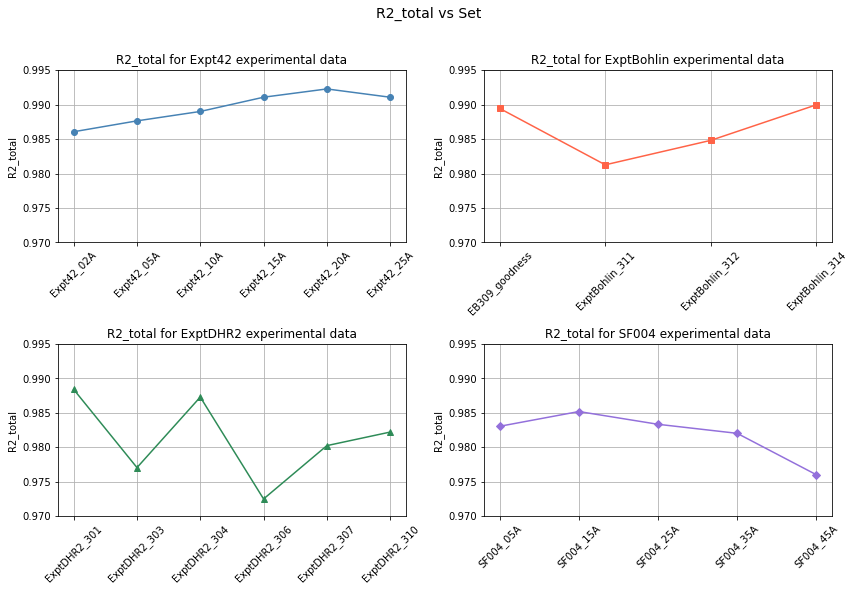

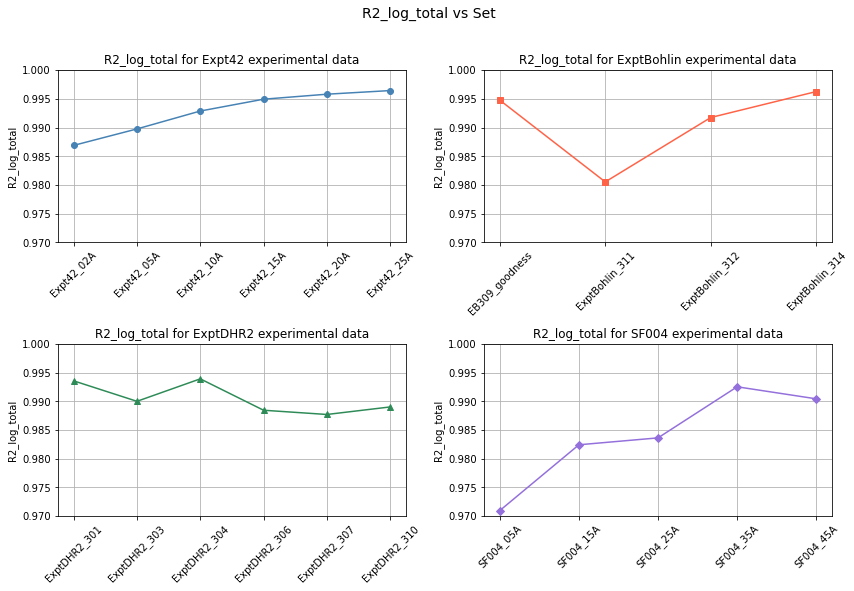

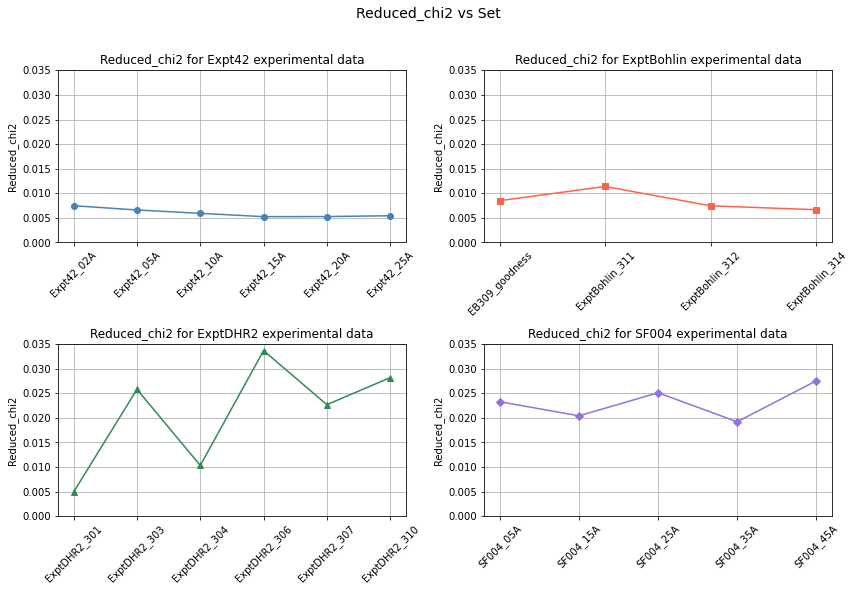

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_r2_subplots(df_by_folder, folders, labels, y_col='R2_total', ylim=(0.97, 0.995)):
    """
    Plots subplots for each folder/dataframe.
    
    Parameters:
        df_by_folder : dict of dataframes
        folders      : list of keys to pull from df_by_folder
        labels       : list of display names for each subplot title
        y_col        : column to plot on y-axis (default 'R2_total')
        ylim         : tuple for y-axis limits (default (0.97, 0.995))
    """
    dataframes = [df_by_folder[f] for f in folders]
    colors = ['steelblue', 'tomato', 'seagreen', 'mediumpurple']
    markers = ['o', 's', '^', 'D']

    # Clean set names
    for df in dataframes:
        df['set'] = df['set'].str.replace('fit_', '', regex=False).str.replace('.bbx_goodness', '', regex=False)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, df, label, color, marker in zip(axes, dataframes, labels, colors, markers):
        ax.plot(df['set'], df[y_col], marker=marker, color=color)
        ax.set_title(f'{y_col} for {label} experimental data')
        ax.set_ylabel(y_col)
        ax.set_ylim(ylim)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True)

    plt.suptitle(f'{y_col} vs Set', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{y_col}_comparison_subplots.png', dpi=150)
    plt.show()


# Define these once and reuse
folders = ['Expt42_data', 'ExptBohlin_data', 'ExptDHR2_data', 'SF004_data']
labels  = ['Expt42', 'ExptBohlin', 'ExptDHR2', 'SF004']

# Call for different columns
plot_r2_subplots(df_by_folder, folders, labels, y_col='R2_total', ylim=(0.97, 0.995))
plot_r2_subplots(df_by_folder, folders, labels, y_col='R2_log_total',   ylim=(0.97, 1))
plot_r2_subplots(df_by_folder, folders, labels, y_col='Reduced_chi2',   ylim=(0, 0.035))

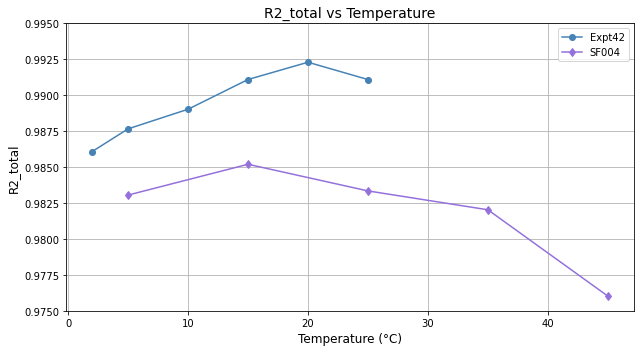

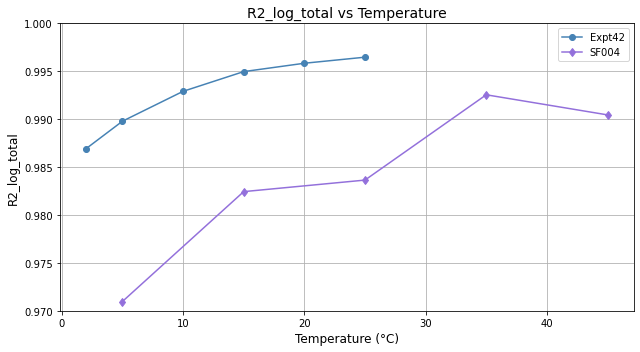

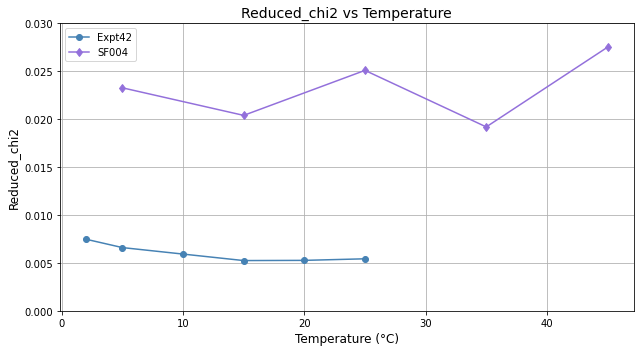

In [41]:
def plot_two_dfs(df_by_folder, folder1, folder2, label1, label2, y_col='R2_total', x_col='temperature', ylim=None):
    """
    Plots two dataframes on the same graph.

    Parameters:
        df_by_folder : dict of dataframes
        folder1/2    : keys to pull from df_by_folder
        label1/2     : legend labels for each dataframe
        y_col        : column to plot on y-axis (default 'R2_total')
        x_col        : column to plot on x-axis (default 'temperature')
        ylim         : tuple for y-axis limits, e.g. (0.97, 0.995). None for auto.
    """
    df1 = df_by_folder[folder1]
    df2 = df_by_folder[folder2]

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot([2,5,10,15,20,25], df1[y_col], marker='o', color='steelblue', label=label1)
    ax.plot([5,15,25,35,45], df2[y_col], marker='d', color='mediumpurple',    label=label2)

    ax.set_xlabel('Temperature (°C)', fontsize=12)
    ax.set_ylabel(y_col, fontsize=12)
    ax.set_title(f'{y_col} vs Temperature', fontsize=14)
    ax.legend()
    ax.grid(True)
    if ylim:
        ax.set_ylim(ylim)

    plt.tight_layout()
    plt.savefig(f'{y_col}_vs_temp_for_TDepend_data.png', dpi=150)
    plt.show()


# Example call
plot_two_dfs(df_by_folder,
             folder1='Expt42_data', folder2='SF004_data',
             label1='Expt42',       label2='SF004',
             y_col='R2_total', ylim=(0.975, 0.995))
plot_two_dfs(df_by_folder,
             folder1='Expt42_data', folder2='SF004_data',
             label1='Expt42',       label2='SF004',
             y_col='R2_log_total', ylim=(0.97, 1))
plot_two_dfs(df_by_folder,
             folder1='Expt42_data', folder2='SF004_data',
             label1='Expt42',       label2='SF004',
             y_col='Reduced_chi2', ylim=(0, 0.03))